#  **About Dataset**

## About Dataset Diabetes is among the most prevalent chronic diseases in the United States, impacting millions of Americans each year and exerting a significant financial burden on the economy. Diabetes is a serious chronic disease in which individuals lose the ability to effectively regulate levels of glucose in the blood, and can lead to reduced quality of life and life expectancy. After different foods are broken down into sugars during digestion, the sugars are then released into the bloodstream. This signals the pancreas to release insulin. Insulin helps enable cells within the body to use those sugars in the bloodstream for energy. Diabetes is generally characterized by either the body not making enough insulin or being unable to use the insulin that is made as effectively as needed.

## Complications like heart disease, vision loss, lower-limb amputation, and kidney disease are associated with chronically high levels of sugar remaining in the bloodstream for those with diabetes. While there is no cure for diabetes, strategies like losing weight, eating healthily, being active, and receiving medical treatments can mitigate the harms of this disease in many patients. Early diagnosis can lead to lifestyle changes and more effective treatment, making predictive models for diabetes risk important tools for public and public health officials.

## The scale of this problem is also important to recognize. The Centers for Disease Control and Prevention has indicated that as of 2018, 34.2 million Americans have diabetes and 88 million have prediabetes. Furthermore, the CDC estimates that 1 in 5 diabetics, and roughly 8 in 10 prediabetics are unaware of their risk. While there are different types of diabetes, type II diabetes is the most common form and its prevalence varies by age, education, income, location, race, and other social determinants of health. Much of the burden of the disease falls on those of lower socioeconomic status as well.

## The Behavioral Risk Factor Surveillance System (BRFSS) is a health-related telephone survey that is collected annually by the CDC. Each year, the survey collects responses from over 400,000 Americans on health-related risk behaviors, chronic health conditions, and the use of preventative services. It has been conducted every year since 1984. For this project, a csv of the dataset available on Kaggle for the year 2015 was used. This original dataset contains responses from 441,455 individuals and has 330 features. These features are either questions directly asked of participants, or calculated variables based on individual participant responses.

# **About Columns**

Diabetes_binary : you have diabetes (0,1)

HighBP : Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional (0,1)

HighChol : Have you EVER been told by a doctor, nurse or other health professional that your blood cholesterol is high? (0,1)

CholCheck : Cholesterol check within past five years (0,1)

BMI : Body Mass Index (BMI)

Smoker : Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] (0,1)

Stroke : (Ever told) you had a stroke. (0,1)

HeartDiseaseorAttack : Respondents that have ever reported having coronary heart disease (CHD) or myocardial infarction (MI) (0,1)

PhysActivity : Adults who reported doing physical activity or exercise during the past 30 days other than their regular job (0,1)

Fruits : Consume Fruit 1 or more times per day (0,1)

Veggies : Consume Vegetables 1 or more times per day (0,1)

HvyAlcoholConsump : Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week)(0,1)

AnyHealthcare : Do you have any kind of health care coverage, including health insurance, prepaid plans such as HMOs, or government plans such as Medicare, or Indian Health Service? (0,1)

NoDocbcCost : Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? (0,1)

GenHlth : Would you say that in general your health is: rate (1 ~ 5)

MentHlth : Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? (0 ~ 30)

PhysHlth : Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? (0 ~ 30)

DiffWalk : Do you have serious difficulty walking or climbing stairs? (0,1)

Sex : Indicate sex of respondent (0,1) (Female or Male)

Age : Fourteen-level age category (1 ~ 14)

Education : What is the highest grade or year of school you completed? (1 ~ 6)

Income : Is your annual household income from all sources: (If respondent refuses at any income level, code "Refused.") (1 ~ 8)

# 1. **Introduction**

### 1.1 Overview of Diabetes & Global Impact
Diabetes mellitus is a chronic metabolic disease characterized by elevated blood glucose levels. According to the International Diabetes Federation (IDF), approximately **537 million adults** live with diabetes worldwide (2021), with projections reaching **783 million by 2045**. The disease causes severe complications including cardiovascular disease, neuropathy, retinopathy, and kidney failure, making it one of the leading causes of premature death and disability globally.

### 1.2 Importance of Early Prediction
Early detection of diabetes enables:
- **Timely medical intervention** before complications arise
- **Lifestyle modifications** that can reverse pre-diabetes
- **Cost reduction** in long-term healthcare
- **Improved quality of life** for at-risk individuals

### 1.3 Machine Learning in Disease Prediction
Traditional screening methods rely on clinical thresholds (fasting glucose > 126 mg/dL), missing many borderline cases. Machine learning offers:
- Pattern recognition across **multiple risk factors simultaneously**
- **Non-invasive** prediction from behavioral and demographic data
- **Scalable** screening across large populations
- Identification of **complex non-linear relationships** between features

### 1.4 Project Objective
> **Build a robust binary classification model to predict whether an individual has diabetes or not, using behavioral risk factors from the BRFSS 2015 survey.**

### 1.5 Problem Definition
| Attribute | Detail |
|-----------|--------|
| **Task Type** | Binary Classification |
| **Target Variable** | `Diabetes_binary` (0 = No Diabetes, 1 = Diabetes) |
| **Dataset** | BRFSS 2015 Health Indicators |
| **Evaluation Priority** | High Recall (minimize missed diabetics) |


 # **Data Exploring**

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)



In [211]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

In [212]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [213]:
df.shape

(253680, 22)

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [215]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [216]:
print(" Summary Statistics:")
df.describe().T

 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


# **2) Data Cleaning**

In [217]:
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [218]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 24206


In [219]:
df.drop_duplicates(inplace=True)


In [220]:
df.duplicated().sum()

np.int64(0)

In [221]:
#Function to view the value counts for the whole data
def v_counts(dataframe):
    for i in dataframe :
        print(dataframe[i].value_counts())
        print("_____________________________________________________________________________")

In [222]:
v_counts(df)

Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64
_____________________________________________________________________________
HighBP
0.0    125214
1.0    104260
Name: count, dtype: int64
_____________________________________________________________________________
HighChol
0.0    128129
1.0    101345
Name: count, dtype: int64
_____________________________________________________________________________
CholCheck
1.0    220176
0.0      9298
Name: count, dtype: int64
_____________________________________________________________________________
BMI
27.0    21514
26.0    17775
24.0    16497
28.0    14914
25.0    14793
        ...  
85.0        1
86.0        1
91.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64
_____________________________________________________________________________
Smoker
0.0    122585
1.0    106889
Name: count, dtype: int64
_____________________________________________________________________________
Stroke
0.0    219

# **3. Exploratory Data Analysis (EDA)**

In [223]:
# df["Diabetes_binary_str"]= df["Diabetes_binary"].replace({0:"NOn-Diabetic",1:"Diabetic"})

In [224]:
data2 = df.copy()

In [225]:
# That help us to show the relation between features clearly

data2.Age[data2['Age'] == 1] = '18 to 24'
data2.Age[data2['Age'] == 2] = '25 to 29'
data2.Age[data2['Age'] == 3] = '30 to 34'
data2.Age[data2['Age'] == 4] = '35 to 39'
data2.Age[data2['Age'] == 5] = '40 to 44'
data2.Age[data2['Age'] == 6] = '45 to 49'
data2.Age[data2['Age'] == 7] = '50 to 54'
data2.Age[data2['Age'] == 8] = '55 to 59'
data2.Age[data2['Age'] == 9] = '60 to 64'
data2.Age[data2['Age'] == 10] = '65 to 69'
data2.Age[data2['Age'] == 11] = '70 to 74'
data2.Age[data2['Age'] == 12] = '75 to 79'
data2.Age[data2['Age'] == 13] = '80 or older'

data2.Diabetes_binary[data2['Diabetes_binary'] == 0] = 'No Diabetes'
data2.Diabetes_binary[data2['Diabetes_binary'] == 1] = 'Diabetes'

data2.HighBP[data2['HighBP'] == 0] = 'No High'
data2.HighBP[data2['HighBP'] == 1] = 'High BP'

data2.HighChol[data2['HighChol'] == 0] = 'No High Cholesterol'
data2.HighChol[data2['HighChol'] == 1] = 'High Cholesterol'

data2.CholCheck[data2['CholCheck'] == 0] = 'No Cholesterol Check '
data2.CholCheck[data2['CholCheck'] == 1] = 'Cholesterol Check'

data2.Smoker[data2['Smoker'] == 0] = 'No'
data2.Smoker[data2['Smoker'] == 1] = 'Yes'

data2.Stroke[data2['Stroke'] == 0] = 'No'
data2.Stroke[data2['Stroke'] == 1] = 'Yes'

data2.HeartDiseaseorAttack[data2['HeartDiseaseorAttack'] == 0] = 'No'
data2.HeartDiseaseorAttack[data2['HeartDiseaseorAttack'] == 1] = 'Yes'

data2.PhysActivity[data2['PhysActivity'] == 0] = 'No'
data2.PhysActivity[data2['PhysActivity'] == 1] = 'Yes'

data2.Fruits[data2['Fruits'] == 0] = 'No'
data2.Fruits[data2['Fruits'] == 1] = 'Yes'

data2.Veggies[data2['Veggies'] == 0] = 'No'
data2.Veggies[data2['Veggies'] == 1] = 'Yes'

data2.HvyAlcoholConsump[data2['HvyAlcoholConsump'] == 0] = 'No'
data2.HvyAlcoholConsump[data2['HvyAlcoholConsump'] == 1] = 'Yes'

data2.AnyHealthcare[data2['AnyHealthcare'] == 0] = 'No'
data2.AnyHealthcare[data2['AnyHealthcare'] == 1] = 'Yes'

data2.NoDocbcCost[data2['NoDocbcCost'] == 0] = 'No'
data2.NoDocbcCost[data2['NoDocbcCost'] == 1] = 'Yes'

data2.GenHlth[data2['GenHlth'] == 5] = 'Excellent'
data2.GenHlth[data2['GenHlth'] == 4] = 'Very Good'
data2.GenHlth[data2['GenHlth'] == 3] = 'Good'
data2.GenHlth[data2['GenHlth'] == 2] = 'Fair'
data2.GenHlth[data2['GenHlth'] == 1] = 'Poor'

data2.DiffWalk[data2['DiffWalk'] == 0] = 'No'
data2.DiffWalk[data2['DiffWalk'] == 1] = 'Yes'

data2.Sex[data2['Sex'] == 0] = 'Female'
data2.Sex[data2['Sex'] == 1] = 'Male'


data2.Education[data2['Education'] == 1] = 'Never Attended School'
data2.Education[data2['Education'] == 2] = 'Elementary'
data2.Education[data2['Education'] == 3] = 'Junior High School'
data2.Education[data2['Education'] == 4] = 'Senior High School'
data2.Education[data2['Education'] == 5] = 'Undergraduate Degree'
data2.Education[data2['Education'] == 6] = 'Magister'

data2.Income[data2['Income'] == 1] = 'Less Than $10,000'
data2.Income[data2['Income'] == 2] = 'Less Than $10,000'
data2.Income[data2['Income'] == 3] = 'Less Than $10,000'
data2.Income[data2['Income'] == 4] = 'Less Than $10,000'
data2.Income[data2['Income'] == 5] = 'Less Than $35,000'
data2.Income[data2['Income'] == 6] = 'Less Than $35,000'
data2.Income[data2['Income'] == 7] = 'Less Than $35,000'
data2.Income[data2['Income'] == 8] = '$75,000 or More'


/tmp/ipykernel_17533/2740628620.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2.Age[data2['Age'] == 1] = '18 to 24'
/tmp/ipykernel_17533/2740628620.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will r

## 1. Class Distribution of the Target variable

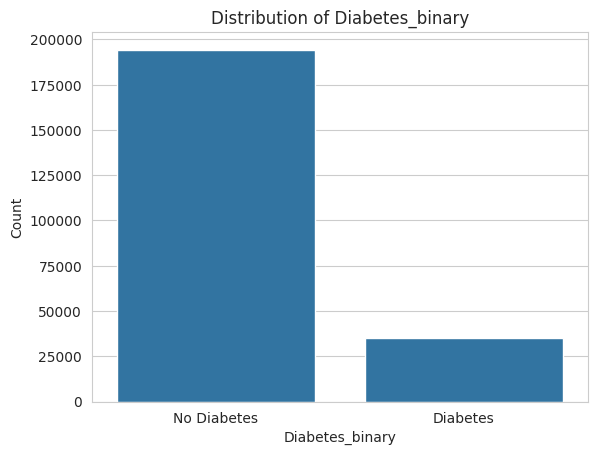

In [226]:

sns.countplot(x='Diabetes_binary', data=data2)

plt.title('Distribution of Diabetes_binary')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')

plt.show()

## **2. Demographic Features**

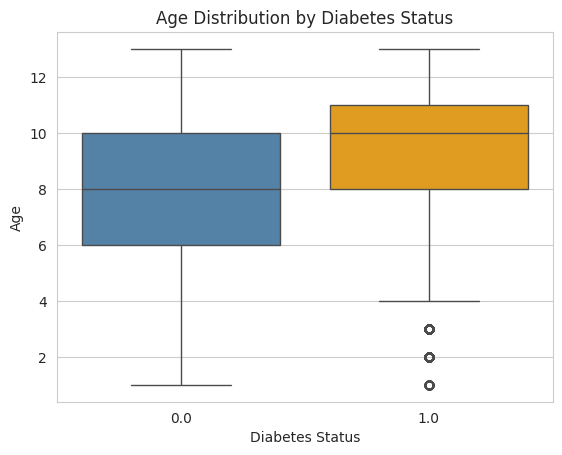

In [227]:
sns.boxplot(
    x='Diabetes_binary',
    y='Age',
    hue='Diabetes_binary',
    data=df,
    palette=['steelblue', 'orange'],
    legend=False
)

plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Age')

plt.show()

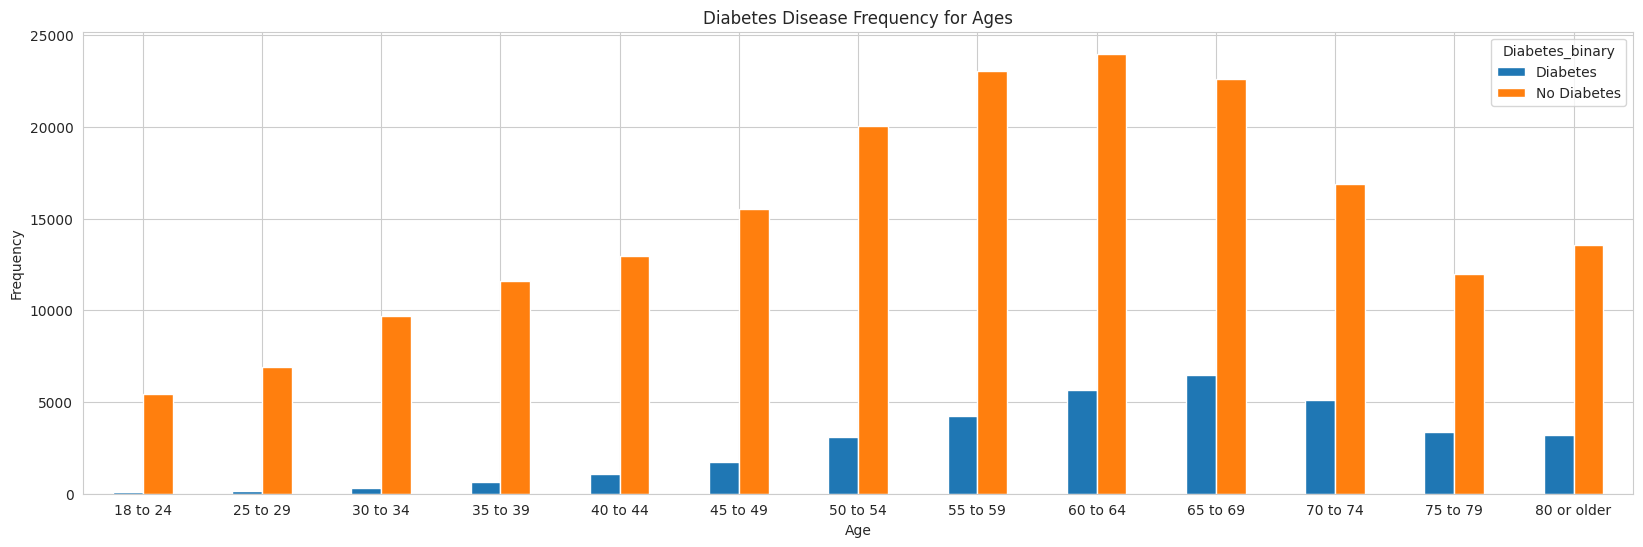

In [228]:
pd.crosstab(data2.Age,data2.Diabetes_binary).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Disease Frequency for Ages')
plt.xlabel('Age')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_17533/3926734333.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


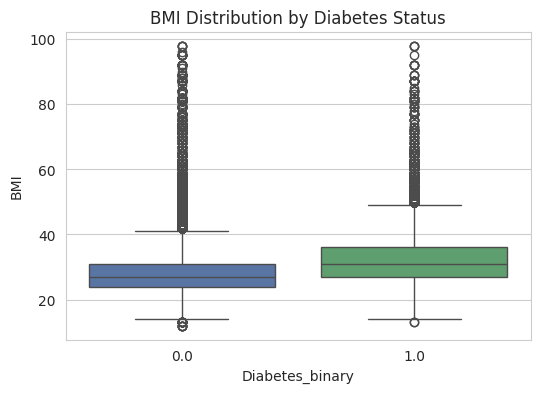

In [229]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    x='Diabetes_binary',
    y='BMI',
    data=df,
    palette=['#4C72B0', '#55A868']
)

plt.title("BMI Distribution by Diabetes Status")
plt.show()


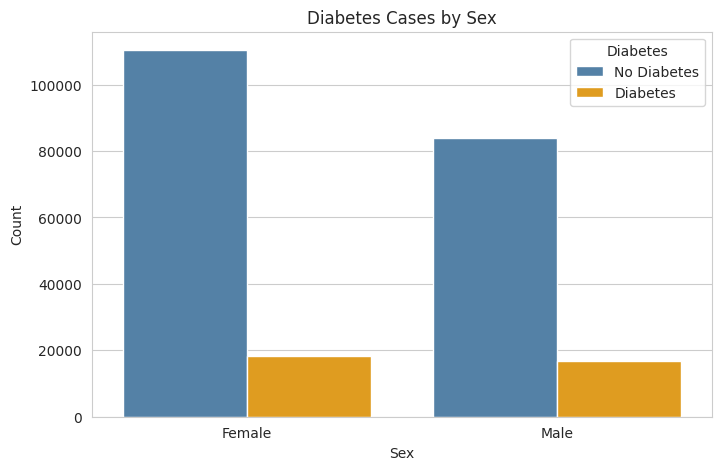

In [230]:

plt.figure(figsize=(8,5))
sns.countplot(
    data=data2,
    x="Sex",
    hue="Diabetes_binary" ,
    palette={"No Diabetes": "steelblue", "Diabetes": "orange"}
)

plt.title("Diabetes Cases by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Diabetes")

plt.show()


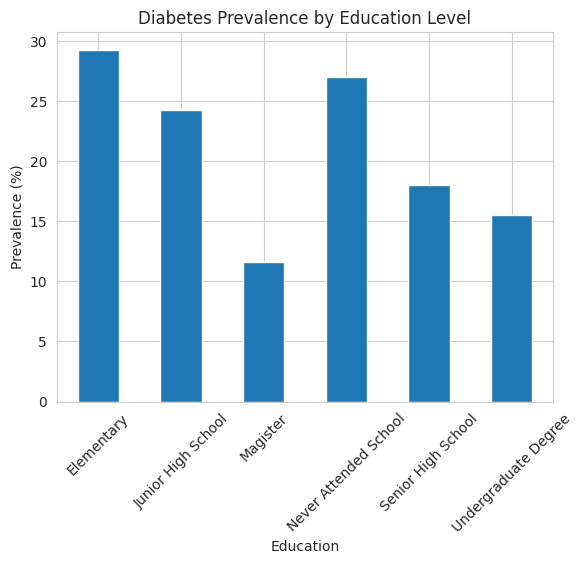

In [231]:

data2['Diabetes_num'] = data2['Diabetes_binary'].map({
    'No Diabetes': 0,
    'Diabetes': 1
})

edu_diabetes = (
    data2.groupby('Education')['Diabetes_num']
    .mean() * 100
)

edu_diabetes.plot(kind='bar')

plt.title('Diabetes Prevalence by Education Level')
plt.xlabel('Education')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=45)

plt.show()

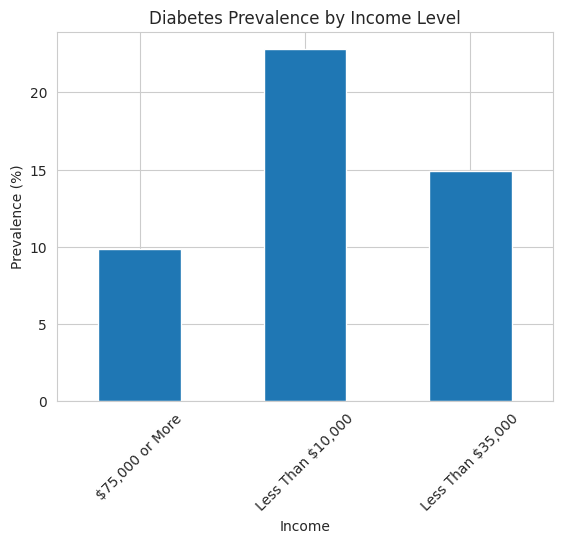

In [232]:
income_diabetes = (
    data2.groupby('Income')['Diabetes_num']
    .mean() * 100
)


income_diabetes.plot(kind='bar')

plt.title('Diabetes Prevalence by Income Level')
plt.xlabel('Income')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=45)

plt.show()

## **3. Cardiovascular Health Conditions**

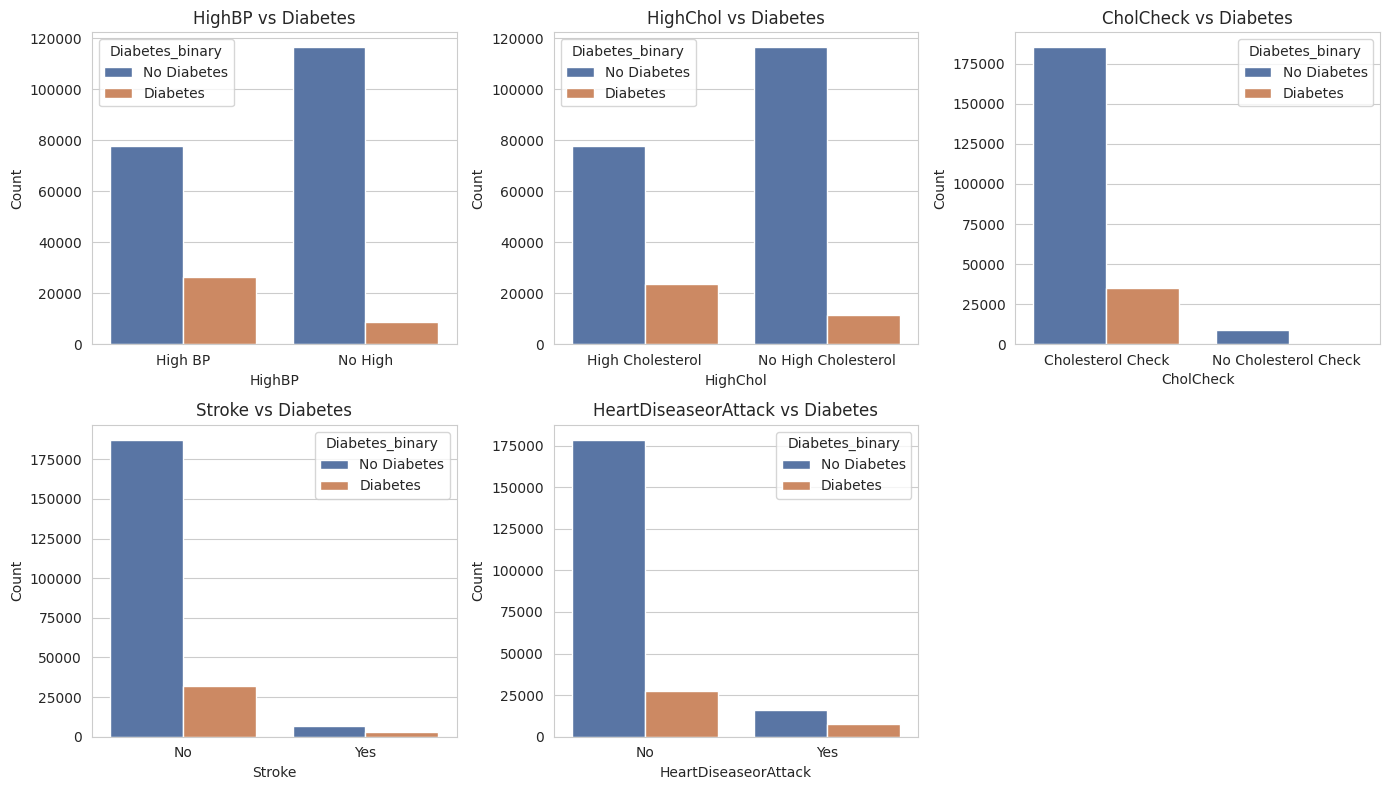

In [233]:

sns.set_style("whitegrid")

cols = ['HighBP', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack']

plt.figure(figsize=(14,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)

    sns.countplot(
        x=col,
        hue='Diabetes_binary',
        data=data2,
        palette=['#4C72B0', '#DD8452']
    )

    plt.title(f'{col} vs Diabetes')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## **4. Lifestyle Factors**

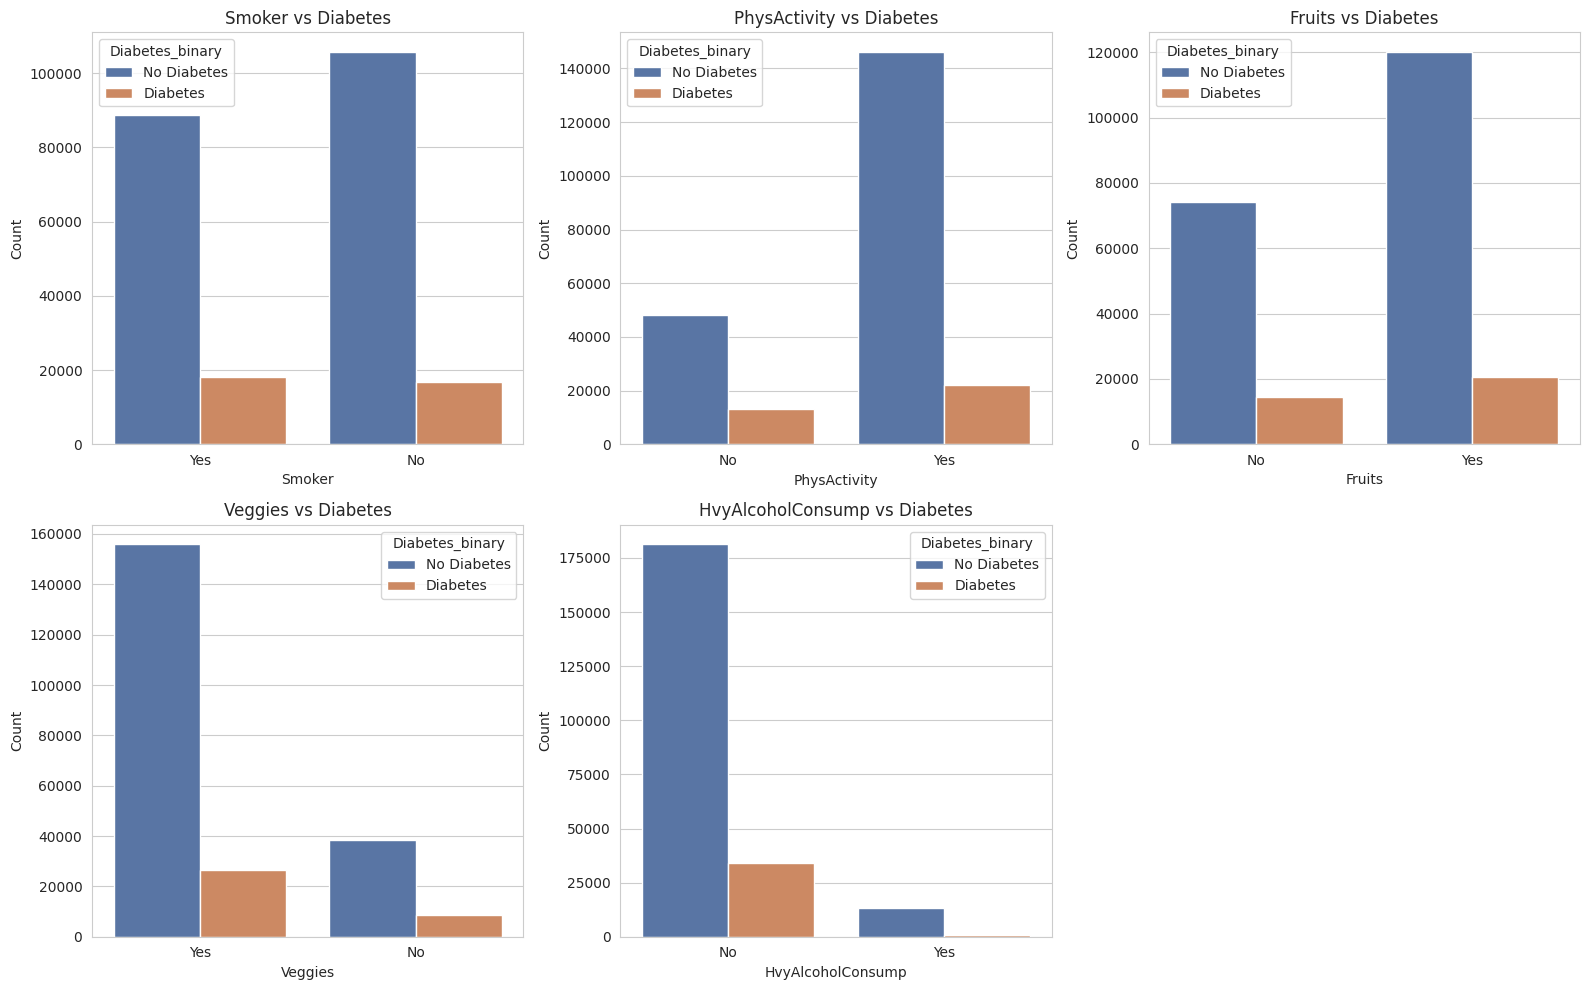

In [234]:

sns.set_style("whitegrid")

cols = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']

plt.figure(figsize=(16,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)

    sns.countplot(
        x=col,
        hue='Diabetes_binary',
        data=data2,
        palette=['#4C72B0', '#DD8452']
    )

    plt.title(f'{col} vs Diabetes')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

##**5. Healthcare Access**

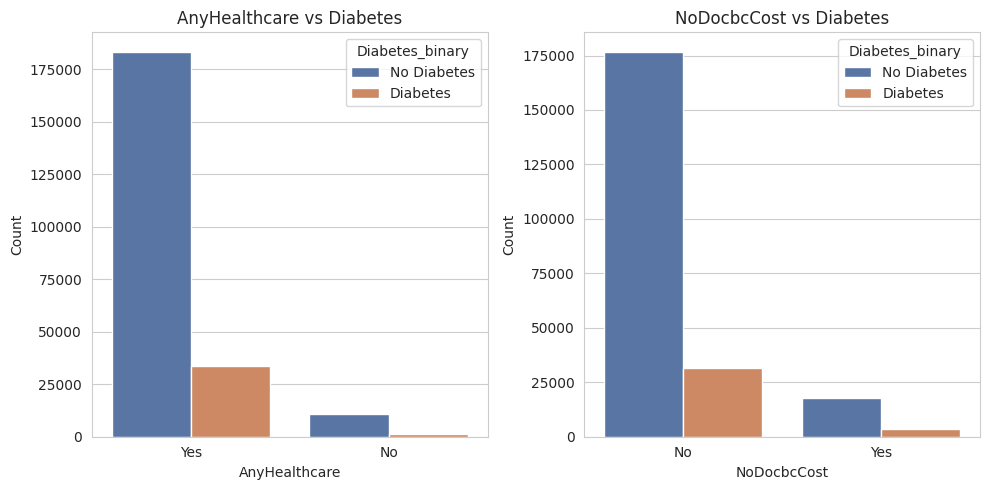

In [235]:

sns.set_style("whitegrid")

cols = ['AnyHealthcare', 'NoDocbcCost']

plt.figure(figsize=(10,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 2, i)

    sns.countplot(
        x=col,
        hue='Diabetes_binary',
        data=data2,
        palette=['#4C72B0', '#DD8452']
    )

    plt.title(f'{col} vs Diabetes')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## **6. Self-Reported Health Status**

Text(0.5, 1.0, 'correlation of feature')

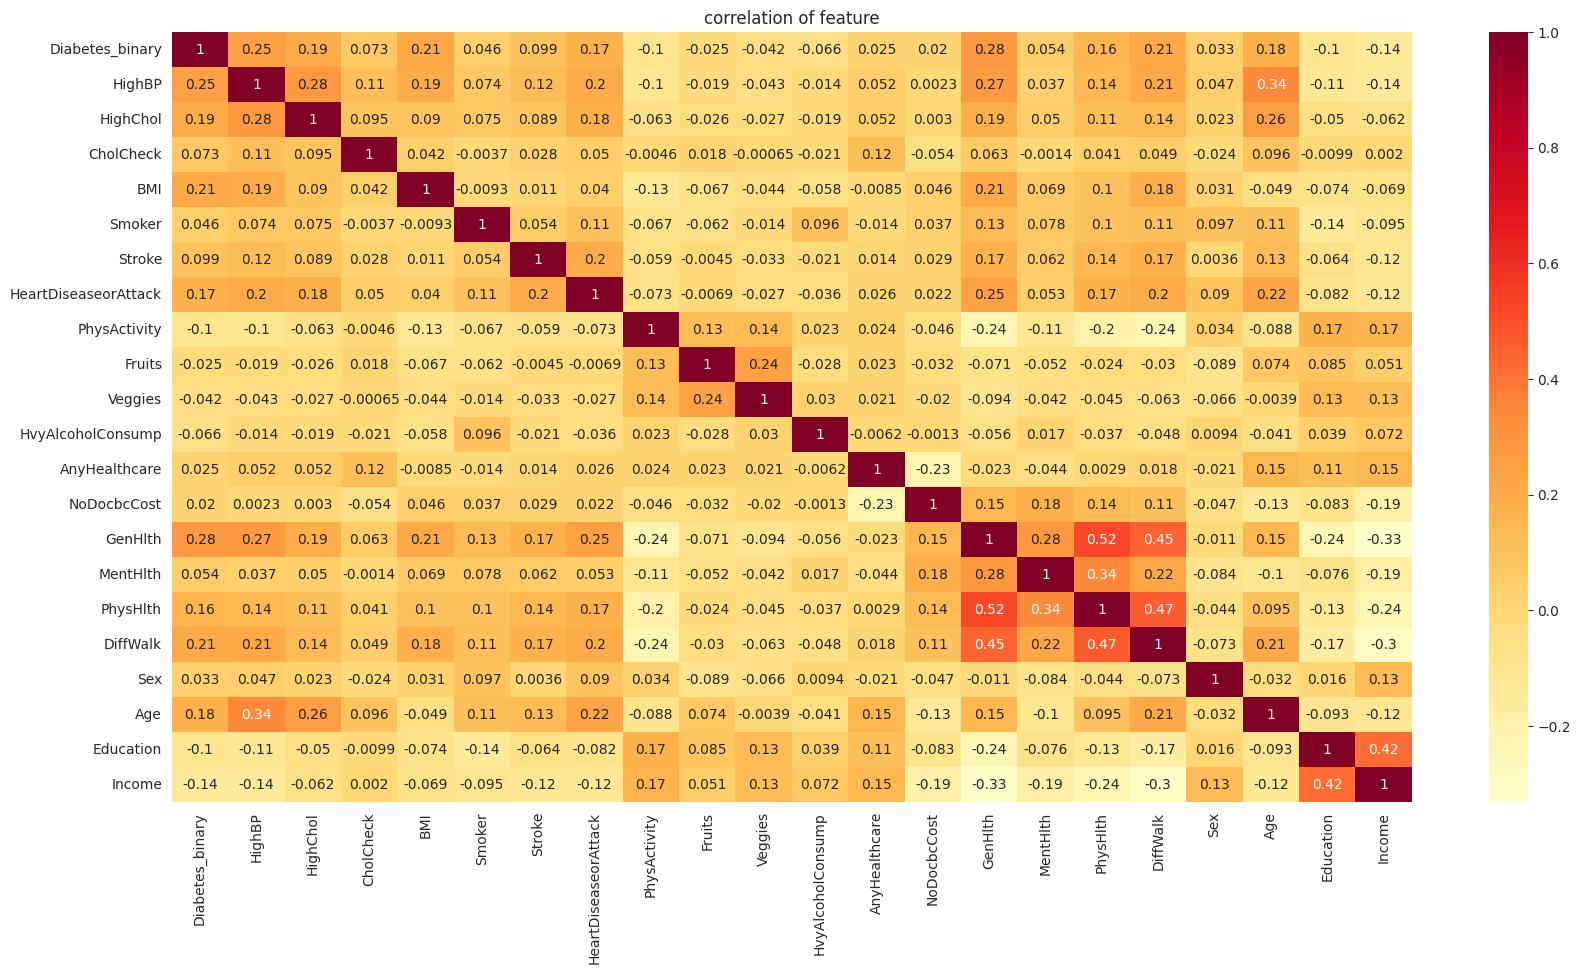

In [236]:
plt.figure(figsize = (20,10))
sns.heatmap(df.corr(),annot=True , cmap ='YlOrRd' )
plt.title("correlation of feature")

**Invalid Value Checks**

Lower Bound: 12.0
Upper Bound: 44.0
Number of Outliers: 5638


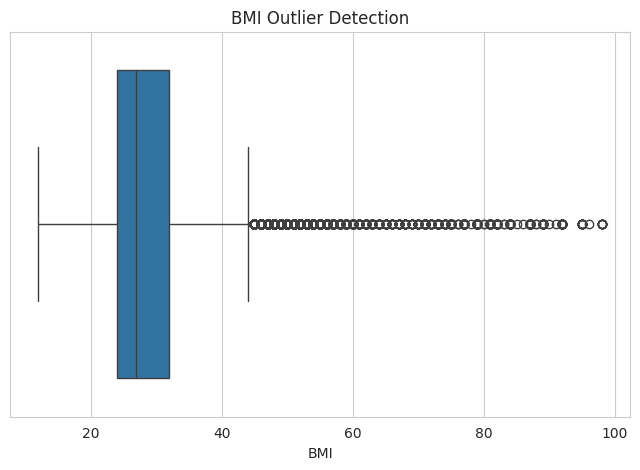

In [237]:

# Outlier Detection for BMI

col = 'BMI'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


bmi_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]


print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(bmi_outliers))


plt.figure(figsize=(8,5))
sns.boxplot(x=df[col])
plt.title("BMI Outlier Detection")
plt.show()








In [238]:
df = df[df['BMI'] <= 70]
df['BMI'].max()

70.0

**Feature Selections**

In [239]:
from sklearn.feature_selection import SelectKBest , chi2 , f_classif
from sklearn.preprocessing import MinMaxScaler

X = df.drop('Diabetes_binary' , axis=1)
y = df['Diabetes_binary']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply Chi-Squared
chi2_selector = SelectKBest(chi2 , k='all')
X_chi2 = chi2_selector.fit_transform(X_scaled , y)
chi_scores = pd.Series(chi2_selector.scores_ , index=X.columns).sort_values(ascending=False)



In [240]:
chi_scores

,0
HighBP,8066.715467
DiffWalk,7831.202543
HeartDiseaseorAttack,5799.828308
HighChol,4859.111777
PhysHlth,3233.310531
GenHlth,3100.301167
Stroke,2147.459324
HvyAlcoholConsump,933.837346
Age,809.615387
PhysActivity,612.408151


In [241]:
# Apply Anova
anova_selector = SelectKBest(f_classif , k='all')
X_anova = anova_selector.fit_transform(X_scaled , y)
anova_scores = pd.Series(anova_selector.scores_ , index=X.columns).sort_values(ascending=False)

In [242]:
anova_scores

,0
GenHlth,18975.117096
HighBP,15808.637971
BMI,12095.088736
DiffWalk,10038.982257
HighChol,9047.445174
Age,7427.798711
HeartDiseaseorAttack,6656.921435
PhysHlth,5681.669262
Income,4594.945262
Education,2439.232924


##**Model-based selection**

In [243]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [244]:
top_features = ['HighBP', 'HighChol', 'BMI', 'Smoker','Stroke', 'HeartDiseaseorAttack', 'PhysActivity','HvyAlcoholConsump','GenHlth','DiffWalk','PhysHlth', 'Sex', 'Age','MentHlth']
X_top = df[top_features]
y = df['Diabetes_binary']
X_top.head()

,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,GenHlth,DiffWalk,PhysHlth,Sex,Age,MentHlth
0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,5.0,1.0,15.0,0.0,9.0,18.0
1,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,7.0,0.0
2,1.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,5.0,1.0,30.0,0.0,9.0,30.0
3,1.0,0.0,27.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,11.0,0.0
4,1.0,1.0,24.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,11.0,3.0


In [279]:

df_class1 = df[df['Diabetes_binary'] == 1]


X_top_class1 = df_class1[X_top.columns]

duplicate_count = X_top_class1.duplicated().sum()

print("Number of duplicate rows in Class 1 (X_top):", duplicate_count)


Number of duplicate rows in Class 1 (X_top): 3672


In [280]:
# Keep only the rows in X_top that are NOT duplicates, and align y accordingly
X_no_dup = X_top.drop_duplicates()
y_no_dup = y.loc[X_no_dup.index]

print(f"X_top shape before drop_duplicates : {X_top.shape}")
print(f"X_no_dup shape after drop_duplicates: {X_no_dup.shape}")
print(f"y_no_dup shape                       : {y_no_dup.shape}")


In [281]:
X_no_dup.duplicated().sum()


np.int64(0)

## **Train Models**

In [246]:

X_train, X_test, y_train, y_test = train_test_split(
    X_no_dup, y_no_dup,
    test_size=0.2,
    random_state=42,
    stratify=y_no_dup
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     38774
         1.0       0.56      0.16      0.25      7004

    accuracy                           0.85     45778
   macro avg       0.71      0.57      0.59     45778
weighted avg       0.82      0.85      0.82     45778



Text(0.5, 1.0, 'Confusion Matrix')

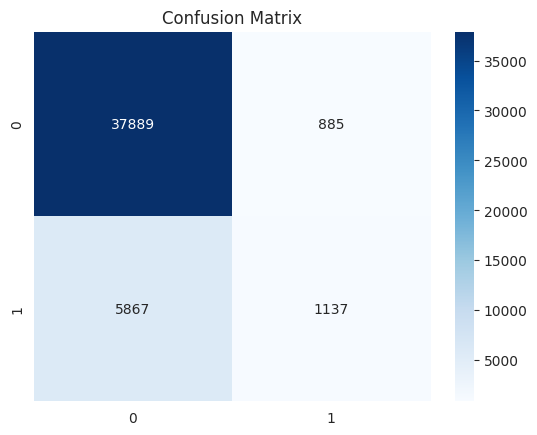

In [248]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

In [249]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=300, max_depth=15)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [250]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.78      0.84     38774
         1.0       0.34      0.64      0.45      7004

    accuracy                           0.76     45778
   macro avg       0.63      0.71      0.65     45778
weighted avg       0.83      0.76      0.78     45778



## **class_weight='balanced'**

In [251]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# حساب الوزن
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# الموديل
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)

xgb.fit(X_train, y_train)

y_pred  = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

scale_pos_weight: 5.54
              precision    recall  f1-score   support

 No Diabetes       0.94      0.70      0.80     38774
    Diabetes       0.32      0.77      0.45      7004

    accuracy                           0.71     45778
   macro avg       0.63      0.73      0.63     45778
weighted avg       0.85      0.71      0.75     45778

ROC-AUC: 0.8110


Text(0.5, 1.0, 'Confusion Matrix')

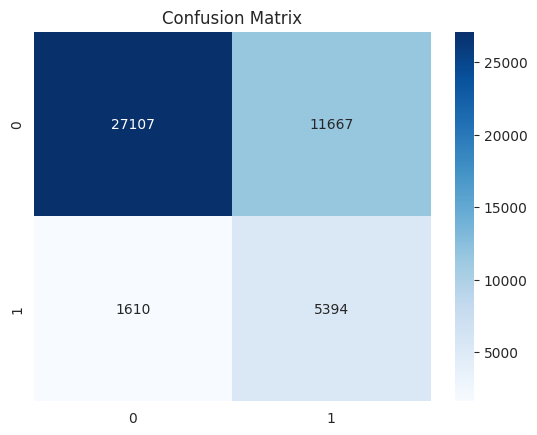

In [252]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

# **Solve Class Imbalnce**

In [253]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_balanced, y_balanced = rus.fit_resample(X_no_dup, y_no_dup)
y_balanced.value_counts()


,count
Diabetes_binary,
0.0,35021
1.0,35021



# **Split**

In [254]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

# **Random Forest**

In [255]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [256]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      7005
         1.0       0.72      0.77      0.74      7004

    accuracy                           0.73     14009
   macro avg       0.73      0.73      0.73     14009
weighted avg       0.73      0.73      0.73     14009



# **xgboost**

In [257]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(random_state=42, n_estimators=100, max_depth=5, objective='binary:logistic')
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      7005
         1.0       0.72      0.77      0.74      7004

    accuracy                           0.73     14009
   macro avg       0.74      0.73      0.73     14009
weighted avg       0.74      0.73      0.73     14009



Text(0.5, 1.0, 'Confusion Matrix')

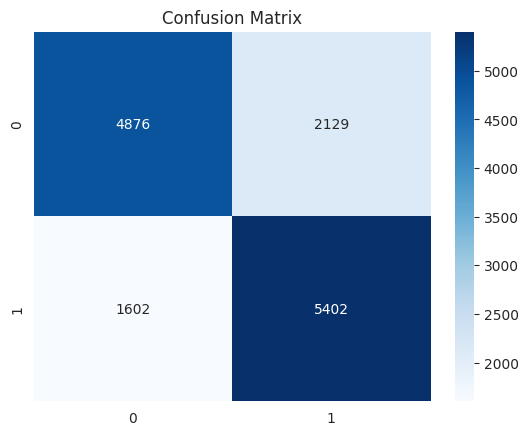

In [258]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

# **Logistic Regression**

In [259]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.71      0.72      7005
         1.0       0.72      0.74      0.73      7004

    accuracy                           0.73     14009
   macro avg       0.73      0.73      0.73     14009
weighted avg       0.73      0.73      0.73     14009



In [260]:
from sklearn.tree import DecisionTreeClassifier
model_tr = DecisionTreeClassifier()
model_tr.fit(X_train, y_train)
y_pred = model_tr.predict(X_test)

In [261]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.64      0.67      0.65      7005
         1.0       0.65      0.62      0.64      7004

    accuracy                           0.65     14009
   macro avg       0.65      0.65      0.64     14009
weighted avg       0.65      0.65      0.64     14009



In [262]:
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier(n_estimators = 200,
max_depth = 3,
random_state = 42,
learning_rate = 0.1)

model_gb.fit(X_train, y_train)
y_pred = model_gb.predict(X_test)

In [263]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.70      0.73      7005
         1.0       0.72      0.77      0.74      7004

    accuracy                           0.74     14009
   macro avg       0.74      0.74      0.74     14009
weighted avg       0.74      0.74      0.74     14009



In [264]:

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2
)


knn_model.fit(X_train, y_train)


y_pred = knn_model.predict(X_test)


print("KNN Results:\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



KNN Results:

              precision    recall  f1-score   support

         0.0       0.69      0.67      0.68      7005
         1.0       0.68      0.69      0.69      7004

    accuracy                           0.68     14009
   macro avg       0.68      0.68      0.68     14009
weighted avg       0.68      0.68      0.68     14009


Confusion Matrix:
[[4710 2295]
 [2139 4865]]


## **Hyperparameter Tuning**

In [265]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_params = {

    'n_estimators': [100, 200, 300],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.01, 0.05, 0.1],

    'subsample': [0.7, 0.8, 1.0],

    'colsample_bytree': [0.7, 0.8, 1.0],

    'min_child_weight': [1, 3, 5]

}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)


xgb_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=xgb_params,

    n_iter=10,

    scoring='f1',

    cv=cv,

    verbose=1,

    n_jobs=-1,

    random_state=42

)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("Best Parameters:\n")
print(xgb_search.best_params_)

print("\n Best Cross Validation F1:")
print(xgb_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:

{'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

 Best Cross Validation F1:
0.7443015541129565


In [266]:
y_pred_xgb = best_xgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      7005
         1.0       0.72      0.76      0.74      7004

    accuracy                           0.73     14009
   macro avg       0.73      0.73      0.73     14009
weighted avg       0.73      0.73      0.73     14009



In [267]:
from sklearn.metrics import roc_auc_score

y_proba = best_xgb.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_proba))

0.8087304144750976


In [268]:
# بعد تدريب أي موديل
train_score =best_xgb.score(X_train, y_train)
test_score  = best_xgb.score(X_test, y_test)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy : {test_score:.4f}")
print(f"الفرق         : {train_score - test_score:.4f}")

Train Accuracy: 0.7344
Test Accuracy : 0.7327
الفرق         : 0.0017


In [276]:
# تأكد إن Test مش فيه بيانات من Train
common = pd.merge(X_train, X_test, how='inner')
print(f"صفوف مشتركة بين Train و Test: {len(common)}")
# المفروض = 0

صفوف مشتركة بين Train و Test: 7939


## **ROC Curve**

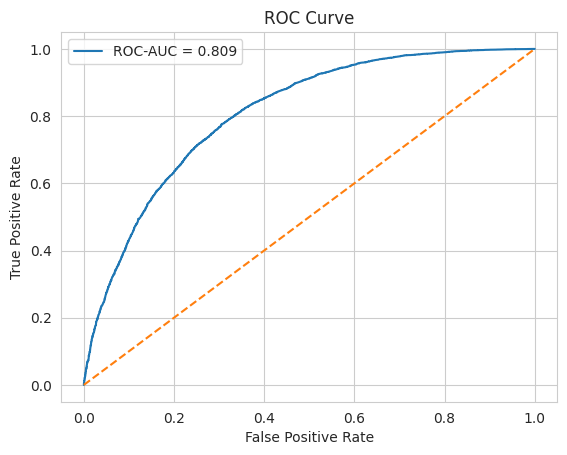

In [270]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)

# Plot
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_val:.3f}")
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



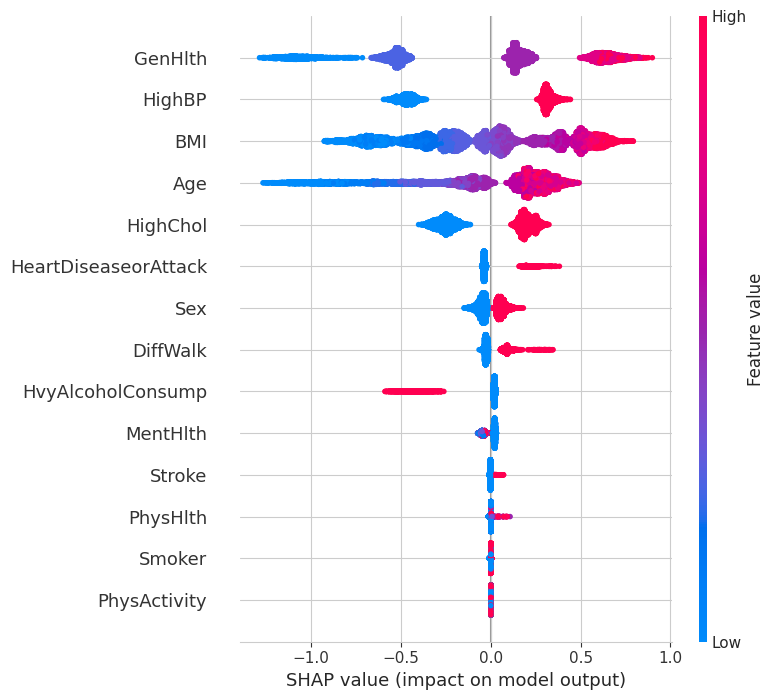

In [271]:
import shap
import matplotlib.pyplot as plt

# create explainer
explainer = shap.TreeExplainer(best_xgb)

# compute SHAP values
shap_values = explainer.shap_values(X_test)

# summary plot
shap.summary_plot(shap_values, X_test)


In [272]:
import joblib

export_data = {
    'model': best_xgb,
    'features': list(X_top.columns)
}

joblib.dump(export_data, 'diabetes_disease_xgb_model.joblib', compress=3)

print("done")

done


In [273]:
# from sklearn.svm import SVC
# svm = SVC(
#     C=10,
#     kernel='rbf',

#     probability=True,
#     random_state=42
# )

# svm.fit(X_train, y_train)

# y_pred  = svm.predict(X_test)
# y_proba = svm.predict_proba(X_test)[:, 1]

# print(classification_report(y_test, y_pred,
#       target_names=['No Diabetes', 'Diabetes']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")